# El carro que todavía sirve

Tu carro prende, gasta lo de siempre y le quedan años. Cambiarlo por uno eléctrico suena a desperdicio: la batería nueva llega con emisiones de fábrica que el carro que ya tienes dejó pagadas hace rato.

Un equipo hizo la cuenta completa para 210 combinaciones de carro de gasolina, carro eléctrico y red eléctrica. En 160 de ellas, retirar el que todavía funciona termina emitiendo menos.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *The climate benefits of retiring a fully operational internal combustion engine vehicle* · Campbell y Geyer, **Science** (6 de agosto de 2026)

**DOI:** [10.1126/science.adv5441](https://doi.org/10.1126/science.adv5441)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-06-retirar-carro-gasolina/notebook.ipynb)

**Video:** [Pendiente]

## Nadie midió carros. Esto es una cuenta

El modelo pone a competir dos cosas. De un lado, las emisiones de fabricar un carro eléctrico, con la batería como partida más pesada. Del otro, la gasolina que el carro viejo dejaría de quemar durante los años que le quedan. Si lo segundo pesa más que lo primero, chatarrizar el carro que funciona y reemplazarlo emite menos en el acumulado.

A ese saldo el paper lo llama **beneficio de retiro**, y lo expresa en porcentaje: 41% quiere decir que, sumando toda la vida útil restante, el escenario de chatarrizar y reemplazar emite 41% menos que el de seguir manejando el de gasolina hasta el final. El número puede ser negativo, y ahí el cambio sale peor.

Cuando un número sale de una cuenta y no de una medición, la pregunta útil no es "¿es cierto?" sino "¿de qué supuestos depende?". Aquí depende sobre todo de uno: **qué tan sucia es la electricidad con la que cargas**. Por eso las tablas repiten la cuenta en tres redes — California (200 g CO₂/kWh), el promedio de EE. UU. (350) y Puerto Rico (699), la más sucia del país.

Todo lo que sigue es Estados Unidos: la flota, la red eléctrica, los kilometrajes y los precios.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RED_PRINCIPAL     = 350      # g CO2/kWh — red de referencia (promedio de EE. UU.)
UMBRAL_RED_SUCIA  = 400      # kg CO2/MWh — corte que usa el paper para "red sucia"
KM_ANIO_REFERENCIA = 20000   # km/año de referencia para los umbrales de kilometraje

FUENTE = ('Fuente: Campbell y Geyer (2026), Science  |  '
          'Datos: Tablas S1-S7 del material suplementario del mismo DOI')

COLOR_DATOS      = '#2563EB'   # azul CaM
COLOR_ALERTA     = '#DC2626'   # rojo
COLOR_SECUNDARIO = '#059669'   # emerald
COLOR_REFERENCIA = '#D97706'   # amber
COLOR_CONTEXTO   = '#BBBBBB'   # gris

# ── Setup ─────────────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-06-retirar-carro-gasolina'


def num_es(x, dec=1):
    """Número al estilo español: miles con punto, decimales con coma."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')


style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)


def cargar(nombre):
    """Lee el CSV local; si no existe (Colab), lo baja del repo."""
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


# ── Carga ─────────────────────────────────────────────────────
matriz      = cargar('beneficio_retiro_matriz.csv')
subredes    = cargar('subredes_electricas_eeuu.csv')
eficiencias = cargar('eficiencias_referencia.csv')
umbrales    = cargar('umbral_kilometraje_anual.csv')

REDES = sorted(matriz.red_g_kwh.unique())
NOMBRE_RED = {200: 'California', 350: 'promedio EE. UU.', 699: 'Puerto Rico'}

print('MATRIZ DE BENEFICIO DE RETIRO')
print(f'  {len(matriz)} casillas = {matriz.vehiculo_ice.nunique()} carros de gasolina/híbridos'
      f' x {matriz.vehiculo_bev.nunique()} eléctricos x {len(REDES)} redes')
print(f'  vacíos: {matriz.beneficio_pct.isna().sum()}')
print(f'  positivos: {(matriz.beneficio_pct > 0).sum()}  |  '
      f'negativos: {(matriz.beneficio_pct < 0).sum()}  |  '
      f'exactamente 0: {(matriz.beneficio_pct == 0).sum()}')
print(f'  asimetría: {stats.skew(matriz.beneficio_pct):.2f}  |  '
      f'curtosis: {stats.kurtosis(matriz.beneficio_pct):.2f}  (cola larga hacia lo negativo)')

print('\nPOR RED')
for r in REDES:
    b = matriz.loc[matriz.red_g_kwh == r, 'beneficio_pct']
    print(f'  {r:>3} g CO2/kWh ({NOMBRE_RED[r]:<16}) '
          f'mediana {b.median():>5.0f}%  IQR [{b.quantile(.25):.0f}, {b.quantile(.75):.0f}]  '
          f'rango [{b.min():.0f}, {b.max():.0f}]  '
          f'positivas {(b > 0).sum()}/{len(b)} ({100 * (b > 0).mean():.0f}%)')

print('\nRED ELÉCTRICA (27 subredes, eGRID 2023)')
media_pond = np.average(subredes.emisiones_kg_mwh, weights=subredes.generacion_neta_mwh)
print(f'  promedio ponderado por generación: {num_es(media_pond)} kg CO2/MWh')
print(f'  promedio simple entre subredes:    {num_es(subredes.emisiones_kg_mwh.mean())} kg CO2/MWh')
print(f'  más limpia: {subredes.loc[subredes.emisiones_kg_mwh.idxmin(), "nombre"]} '
      f'({subredes.emisiones_kg_mwh.min()})  |  '
      f'más sucia: {subredes.loc[subredes.emisiones_kg_mwh.idxmax(), "nombre"]} '
      f'({subredes.emisiones_kg_mwh.max()})')

MATRIZ DE BENEFICIO DE RETIRO
  210 casillas = 10 carros de gasolina/híbridos x 7 eléctricos x 3 redes
  vacíos: 0
  positivos: 160  |  negativos: 48  |  exactamente 0: 2
  asimetría: -1.51  |  curtosis: 2.67  (cola larga hacia lo negativo)

POR RED
  200 g CO2/kWh (California      ) mediana    54%  IQR [39, 66]  rango [-16, 80]  positivas 64/70 (91%)
  350 g CO2/kWh (promedio EE. UU.) mediana    41%  IQR [20, 56]  rango [-50, 75]  positivas 60/70 (86%)
  699 g CO2/kWh (Puerto Rico     ) mediana     4%  IQR [-30, 29]  rango [-144, 60]  positivas 36/70 (51%)

RED ELÉCTRICA (27 subredes, eGRID 2023)
  promedio ponderado por generación: 347,5 kg CO2/MWh
  promedio simple entre subredes:    395,4 kg CO2/MWh
  más limpia: NPCC Upstate NY (110)  |  más sucia: Puerto Rico Miscellaneous (699)


Aquí está.

Cada casilla es un cambio posible: el carro de gasolina que se retira, por el eléctrico que lo reemplaza.

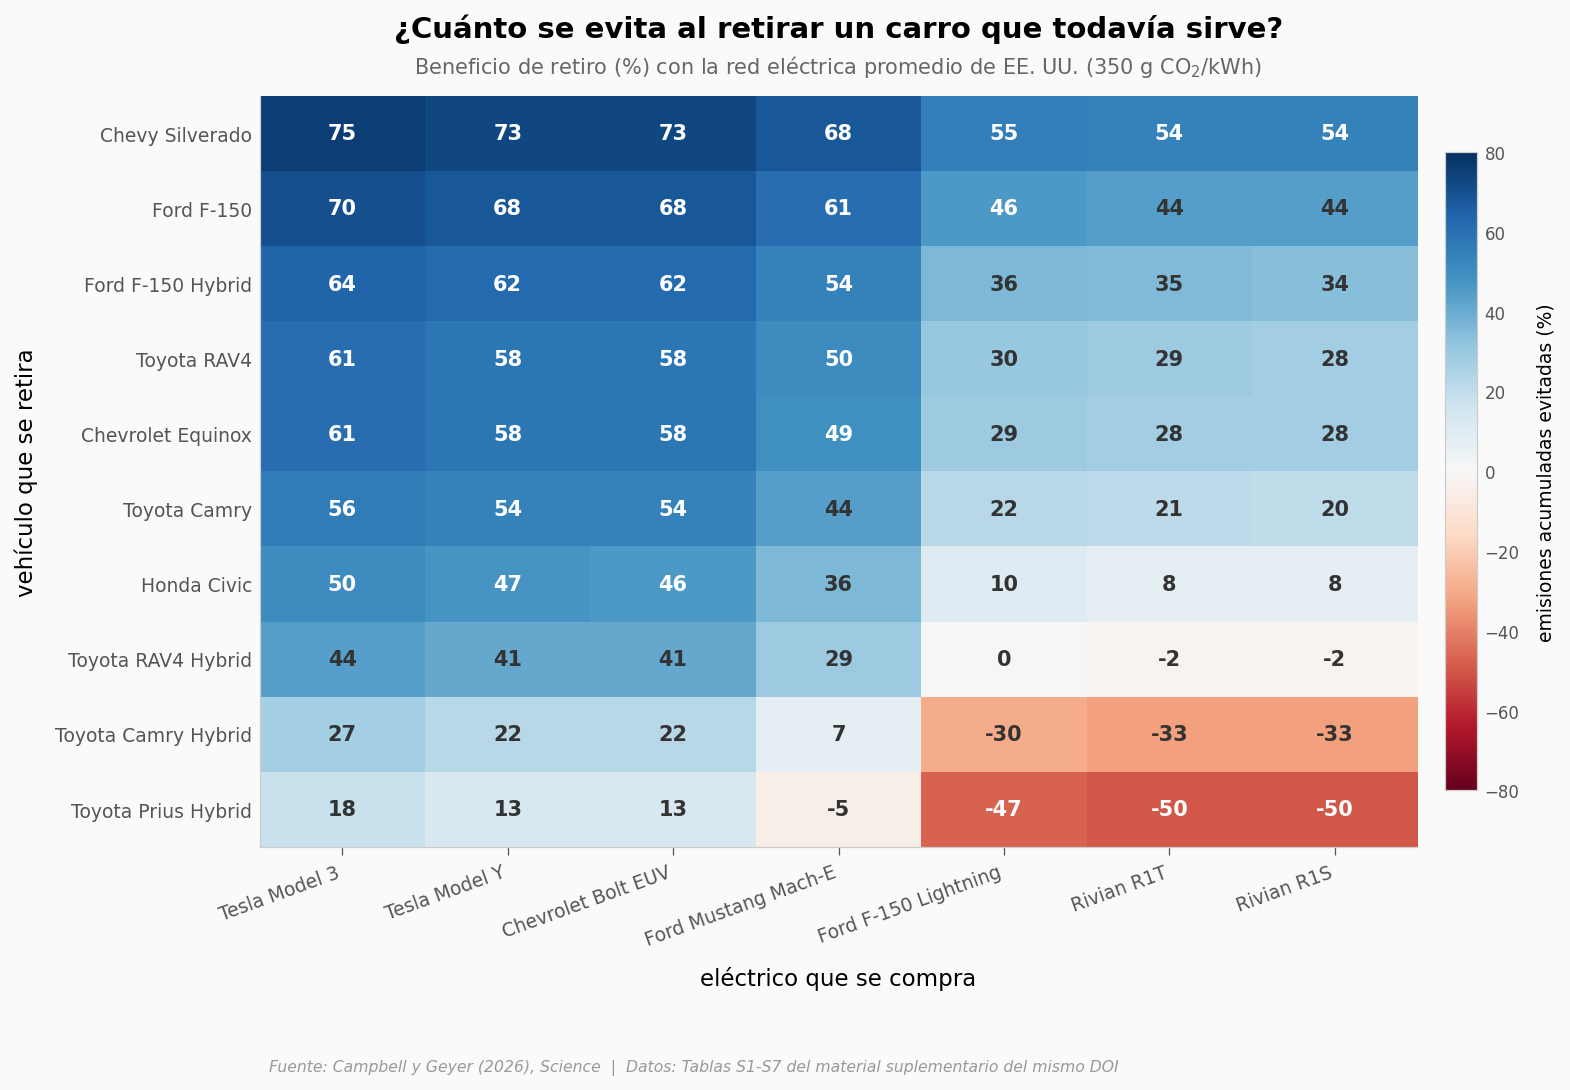

A 350 g CO2/kWh: 60/70 casillas con beneficio positivo (86%), mediana 41%


In [2]:
g = matriz[matriz.red_g_kwh == RED_PRINCIPAL]

# Filas y columnas ordenadas por su mediana (mayor beneficio arriba / a la izquierda)
orden_ice = g.groupby('vehiculo_ice').beneficio_pct.median().sort_values(ascending=False).index
orden_bev = g.groupby('vehiculo_bev').beneficio_pct.median().sort_values(ascending=False).index
piv = g.pivot(index='vehiculo_ice', columns='vehiculo_bev',
              values='beneficio_pct').loc[orden_ice, orden_bev]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(piv.values, cmap='RdBu', vmin=-80, vmax=80, aspect='auto')

for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=10,
                fontweight='bold', color='white' if abs(v) > 45 else '#333333')

ax.set_xticks(range(piv.shape[1]))
ax.set_xticklabels(piv.columns, fontsize=9, rotation=20, ha='right')
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels(piv.index, fontsize=9)
ax.set_xlabel('eléctrico que se compra', fontsize=11)
ax.set_ylabel('vehículo que se retira', fontsize=11)
ax.grid(False)
ax.set_title('¿Cuánto se evita al retirar un carro que todavía sirve?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Beneficio de retiro (%) con la red eléctrica promedio de EE. UU. '
        '(350 g CO$_2$/kWh)', transform=ax.transAxes, fontsize=10,
        color='#666666', ha='center')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('emisiones acumuladas evitadas (%)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.text(0.13, -0.12, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/matriz_beneficio_350.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'A {RED_PRINCIPAL} g CO2/kWh: {(g.beneficio_pct > 0).sum()}/{len(g)} casillas con beneficio positivo '
      f'({100 * (g.beneficio_pct > 0).mean():.0f}%), mediana {g.beneficio_pct.median():.0f}%')

## Lo que sale de la matriz

Con la red promedio de EE. UU., 60 de las 70 combinaciones dan positivo (86%) y la mediana queda en 41% — la mitad de los cambios posibles evita más del 41% de las emisiones acumuladas. El rango es enorme, eso sí: de -50% a +75%, con un IQR de 20 a 56 puntos. No hay un número único que resuma esto.

Lo que decide no es tanto la marca como **el tamaño de lo que se retira**. Retirar una camioneta tiene mediana 61%; un SUV, 41%; un carro pequeño, 19%. Y al revés, en lo que se compra: un carro eléctrico deja mediana 57%, una camioneta eléctrica apenas 25%. Retirar mucho consumo y reemplazarlo con poco es donde están las casillas más azules.

El bloque rojo tiene nombre propio: los híbridos. A esta misma red, un híbrido que se retira deja mediana 20% frente al 50% de los que no lo son — el híbrido ya quemaba poco, así que la batería nueva tiene menos que compensar. El fondo de la tabla es un Toyota Prius cambiado por un Rivian R1S: -50%. Ese cambio emite la mitad más.

## La palanca es el enchufe

Toda esta cuenta se apoya en un supuesto que no está en el carro sino en el cable: de dónde sale la electricidad. Las mismas 70 combinaciones, movidas por las tres redes.

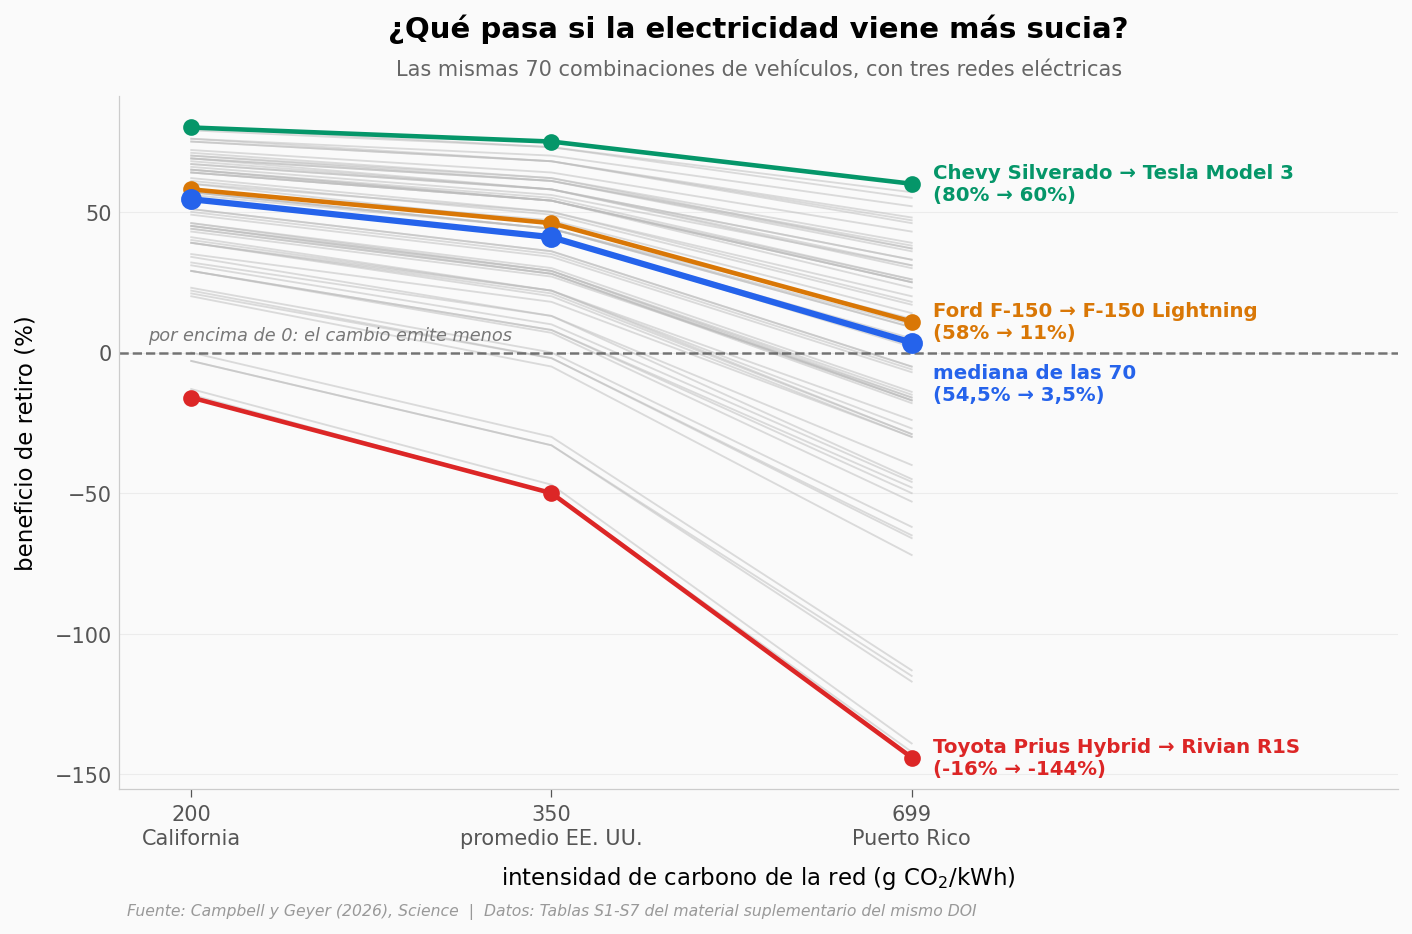

200 g CO2/kWh: mediana  54.5%  |  positivas 64/70 (91%)
350 g CO2/kWh: mediana  41.0%  |  positivas 60/70 (86%)
699 g CO2/kWh: mediana   3.5%  |  positivas 36/70 (51%)

A 699 g CO2/kWh, retirando un híbrido: mediana -29.5%, solo 25% de los casos dan positivo (n=28)


In [3]:
piv3 = matriz.pivot_table(index=['vehiculo_ice', 'vehiculo_bev'],
                          columns='red_g_kwh', values='beneficio_pct')
x = np.arange(len(REDES))

destacados = [
    (('Chevy Silverado', 'Tesla Model 3'), 'Chevy Silverado → Tesla Model 3', COLOR_SECUNDARIO),
    (('Ford F-150', 'Ford F-150 Lightning'), 'Ford F-150 → F-150 Lightning', COLOR_REFERENCIA),
    (('Toyota Prius Hybrid', 'Rivian R1S'), 'Toyota Prius Hybrid → Rivian R1S', COLOR_ALERTA),
]

fig, ax = plt.subplots(figsize=(11, 6))
for _, fila in piv3.iterrows():
    ax.plot(x, fila[REDES].values, color=COLOR_CONTEXTO, lw=0.9, alpha=0.5, zorder=2)

medianas = [matriz.loc[matriz.red_g_kwh == r, 'beneficio_pct'].median() for r in REDES]
ax.plot(x, medianas, color=COLOR_DATOS, lw=3, marker='o', markersize=9, zorder=6)

etiquetas = [(medianas[-1], f'mediana de las 70\n({num_es(medianas[0])}% → {num_es(medianas[-1])}%)',
              COLOR_DATOS)]
for par, nombre, color in destacados:
    y = piv3.loc[par, REDES].values
    ax.plot(x, y, color=color, lw=2.2, marker='o', markersize=7, zorder=5)
    etiquetas.append((y[-1], f'{nombre}\n({y[0]:.0f}% → {y[-1]:.0f}%)', color))

# Separar verticalmente las etiquetas que quedan a menos de 22 puntos una de otra
etiquetas.sort(key=lambda t: -t[0])
y_texto, previo = [], None
for y_fin, _, _ in etiquetas:
    y = y_fin if previo is None else min(y_fin, previo - 22)
    y_texto.append(y)
    previo = y
for (y_fin, texto, color), y in zip(etiquetas, y_texto):
    ax.text(x[-1] + 0.06, y, texto, fontsize=9.5, color=color,
            fontweight='bold', va='center')

ax.axhline(0, color='#555555', lw=1.2, ls='--', alpha=0.8)
ax.text(-0.12, 3, 'por encima de 0: el cambio emite menos', fontsize=8.5,
        color='#777777', style='italic', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels([f'{r}\n{NOMBRE_RED[r]}' for r in REDES], fontsize=10)
ax.set_xlim(-0.2, len(REDES) - 1 + 1.35)
ax.set_xlabel('intensidad de carbono de la red (g CO$_2$/kWh)', fontsize=11)
ax.set_ylabel('beneficio de retiro (%)', fontsize=11)
ax.set_title('¿Qué pasa si la electricidad viene más sucia?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las mismas 70 combinaciones de vehículos, con tres redes eléctricas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/beneficio_por_red.png', dpi=200, bbox_inches='tight')
plt.show()

for r in REDES:
    b = matriz.loc[matriz.red_g_kwh == r, 'beneficio_pct']
    print(f'{r:>3} g CO2/kWh: mediana {b.median():>5.1f}%  |  '
          f'positivas {(b > 0).sum()}/{len(b)} ({100 * (b > 0).mean():.0f}%)')

hib = matriz[(matriz.red_g_kwh == 699) & (matriz.ice_es_hibrido == 1)]
print(f'\nA 699 g CO2/kWh, retirando un híbrido: mediana {hib.beneficio_pct.median():.1f}%, '
      f'solo {100 * (hib.beneficio_pct > 0).mean():.0f}% de los casos dan positivo (n={len(hib)})')

## ¿Y qué tan sucia es la red, de verdad?

Si el resultado depende del enchufe, la pregunta se corre de lugar: cuánta electricidad de Estados Unidos sale de cada tipo de red. El país no tiene una sola — tiene 27 subredes, y entre la más limpia y la más sucia hay un factor de 6,4.

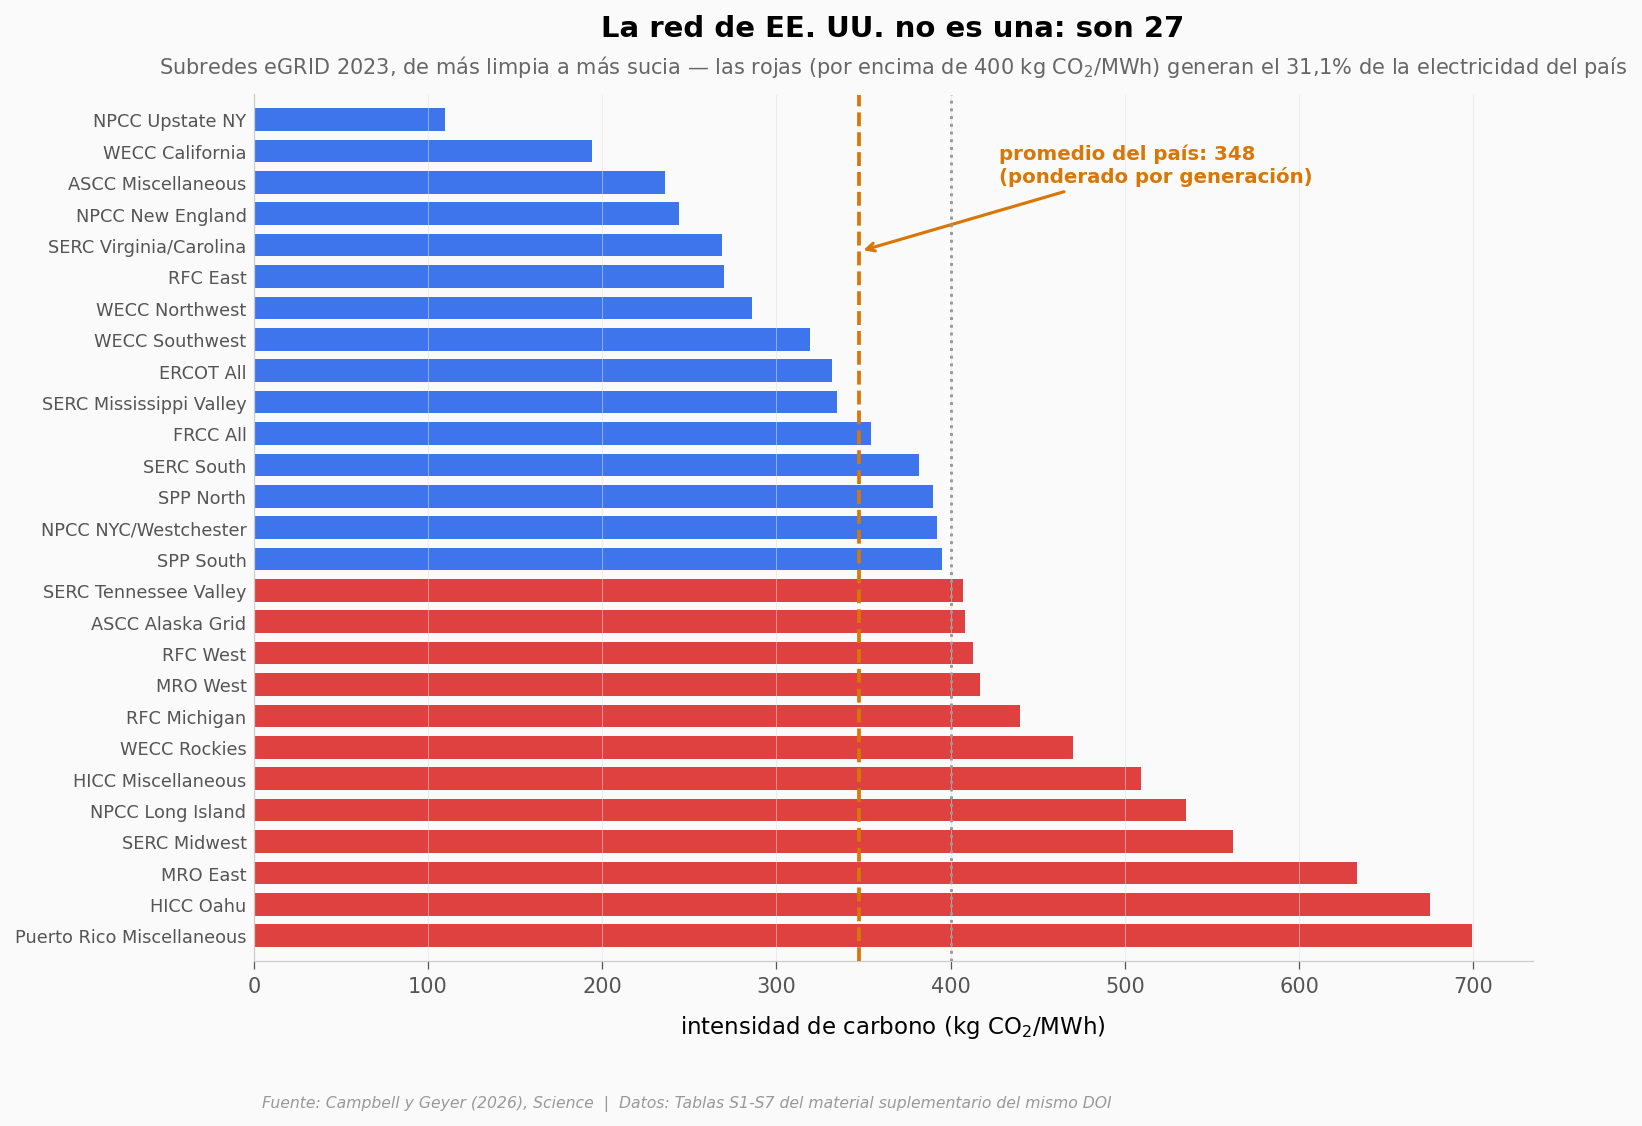

Generación total: 4.191 TWh
Promedio ponderado 347,5 vs promedio simple 395,4 kg CO2/MWh
Mediana 392  |  IQR [302, 455]
Factor entre extremos: 6.4x


In [4]:
s = subredes.sort_values('emisiones_kg_mwh').reset_index(drop=True)
media_pond = np.average(s.emisiones_kg_mwh, weights=s.generacion_neta_mwh)
gen_total = s.generacion_neta_mwh.sum()
frac_sucia = 100 * s.loc[s.emisiones_kg_mwh > UMBRAL_RED_SUCIA, 'generacion_neta_mwh'].sum() / gen_total

colores = [COLOR_ALERTA if v > UMBRAL_RED_SUCIA else COLOR_DATOS for v in s.emisiones_kg_mwh]

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.barh(range(len(s)), s.emisiones_kg_mwh, color=colores, alpha=0.88, height=0.72)
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s.nombre, fontsize=8.5)
ax.set_ylim(-0.8, len(s) - 0.2)
ax.invert_yaxis()
ax.xaxis.grid(True)
ax.yaxis.grid(False)

ax.axvline(media_pond, color=COLOR_REFERENCIA, ls='--', lw=1.8, zorder=4)
ax.annotate(f'promedio del país: {media_pond:.0f}\n(ponderado por generación)',
            xy=(media_pond, 4.2), xytext=(media_pond + 80, 2.0),
            fontsize=9.5, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.5))
ax.axvline(UMBRAL_RED_SUCIA, color='#999999', ls=':', lw=1.4, zorder=3)

ax.set_xlabel('intensidad de carbono (kg CO$_2$/MWh)', fontsize=11)
ax.set_title('La red de EE. UU. no es una: son 27',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.025, f'Subredes eGRID 2023, de más limpia a más sucia — las rojas '
        f'(por encima de {UMBRAL_RED_SUCIA} kg CO$_2$/MWh) generan el '
        f'{num_es(frac_sucia)}% de la electricidad del país',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/subredes_intensidad.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Generación total: {num_es(gen_total / 1e6, 0)} TWh')
print(f'Promedio ponderado {num_es(media_pond)} vs promedio simple '
      f'{num_es(s.emisiones_kg_mwh.mean())} kg CO2/MWh')
print(f'Mediana {s.emisiones_kg_mwh.median():.0f}  |  '
      f'IQR [{s.emisiones_kg_mwh.quantile(.25):.0f}, {s.emisiones_kg_mwh.quantile(.75):.0f}]')
print(f'Factor entre extremos: {s.emisiones_kg_mwh.max() / s.emisiones_kg_mwh.min():.1f}x')

## Las 210 cuentas, de una vez

Casilla por casilla se ven los casos. Todas juntas se ve la forma del resultado — y dónde cae el cero.

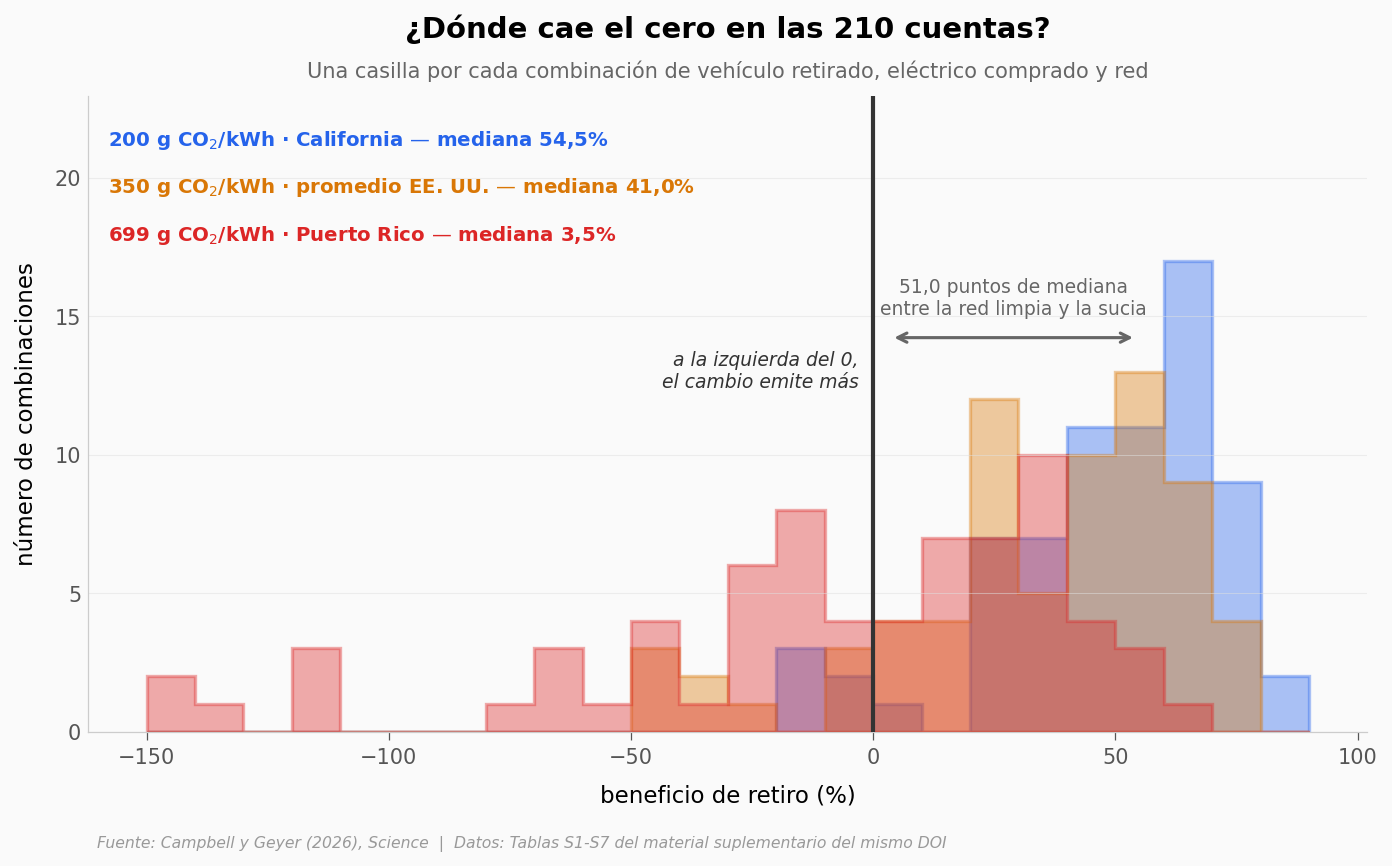

160 de 210 casillas con beneficio positivo (76.2%), 48 negativas, 2 en cero exacto
Asimetría -1.51: la cola larga está del lado negativo — los casos malos son pocos pero se van muy abajo


In [5]:
bins = np.arange(-150, 91, 10)
colores_red = {200: COLOR_DATOS, 350: COLOR_REFERENCIA, 699: COLOR_ALERTA}

fig, ax = plt.subplots(figsize=(11, 5.5))
pico = 0
for r in REDES:
    b = matriz.loc[matriz.red_g_kwh == r, 'beneficio_pct']
    n, _, _ = ax.hist(b, bins=bins, color=colores_red[r], alpha=0.38,
                      edgecolor=colores_red[r], linewidth=1.6, histtype='stepfilled')
    pico = max(pico, n.max())

y_max = pico * 1.35
ax.set_ylim(0, y_max)
ax.axvline(0, color='#333333', lw=2, zorder=5)
ax.text(-3, y_max * 0.60, 'a la izquierda del 0,\nel cambio emite más',
        fontsize=9, color='#333333', va='top', ha='right', style='italic')

med_lim = matriz.loc[matriz.red_g_kwh == 200, 'beneficio_pct'].median()
med_suc = matriz.loc[matriz.red_g_kwh == 699, 'beneficio_pct'].median()
ax.annotate('', xy=(med_lim, y_max * 0.62), xytext=(med_suc, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((med_lim + med_suc) / 2, y_max * 0.65,
        f'{num_es(med_lim - med_suc)} puntos de mediana\nentre la red limpia y la sucia',
        fontsize=9, color='#666666', ha='center', va='bottom')

for k, r in enumerate(REDES):
    b = matriz.loc[matriz.red_g_kwh == r, 'beneficio_pct']
    ax.text(0.015, 0.95 - 0.075 * k,
            f'{r} g CO$_2$/kWh · {NOMBRE_RED[r]} — mediana {num_es(b.median())}%',
            transform=ax.transAxes, fontsize=9.5, fontweight='bold',
            color=colores_red[r], va='top')

ax.set_xlabel('beneficio de retiro (%)', fontsize=11)
ax.set_ylabel('número de combinaciones', fontsize=11)
ax.set_title('¿Dónde cae el cero en las 210 cuentas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Una casilla por cada combinación de vehículo retirado, '
        'eléctrico comprado y red', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_beneficio.png', dpi=200, bbox_inches='tight')
plt.show()

n_pos = (matriz.beneficio_pct > 0).sum()
print(f'{n_pos} de {len(matriz)} casillas con beneficio positivo '
      f'({100 * n_pos / len(matriz):.1f}%), {(matriz.beneficio_pct < 0).sum()} negativas, '
      f'{(matriz.beneficio_pct == 0).sum()} en cero exacto')
print(f'Asimetría {stats.skew(matriz.beneficio_pct):.2f}: la cola larga está del lado negativo — '
      'los casos malos son pocos pero se van muy abajo')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Retirar un carro de gasolina que todavía funciona reduce emisiones acumuladas en la mayoría de los escenarios | ✅ | 160 de 210 casillas dan positivo (76,2%); con la red promedio de EE. UU., 60 de 70 (86%), mediana 41% (IQR 20–56). El resumen del paper trae el mismo alcance: *en la mayoría de los contextos*, no en todos |
| La intensidad de la red eléctrica es la palanca principal | ✅ | La mediana pasa de 54,5% (200 g/kWh) a 41% (350) a 3,5% (699), y las casillas positivas de 91% a 86% a 51% |
| Retirar un híbrido eficiente puede salir peor | ✅ | Con red sucia (699), los híbridos retirados tienen mediana −29,5% y solo el 25% de los casos da positivo (n=28). El peor par, Prius → Rivian R1S, llega a −144% |
| Pesa más el tamaño de lo que se retira y de lo que se compra que la marca | ✅ | A 350 g/kWh: camioneta retirada 61% vs carro 19%; carro eléctrico comprado 57% vs camioneta eléctrica 25% |
| El promedio de la red de EE. UU. es 348 kg CO₂/MWh | ✅ | Nuestra reconstrucción desde la Tabla S3 da 347,5 (0,1% de diferencia). Ponderado por generación, no promedio simple entre subredes — ese da 395,4 |
| «El 92% de los escenarios da reducción neta» | ⚠️ | Es del análisis continuo del paper (Fig. 2A), no de estas tablas. Nuestra matriz discreta da 76,2% porque un tercio de sus casillas usa Puerto Rico (699 g/kWh), el extremo sucio. No son la misma métrica y no se pueden intercambiar |
| Las subredes por encima de 400 kg/MWh son un tercio de la generación | ⚠️ | El paper dice 33%; nuestra reconstrucción con corte estricto >400 da 31,1% (con ≥395 daría 34,9%). La diferencia está en dónde se pone el corte, no en las unidades |
| «Retirar la camioneta más vendida rinde 55%» | ⚠️ | La Tabla S5 da 46% para Ford F-150 → F-150 Lightning a 350 g/kWh. El 55% del texto promedia dos enfoques sobre la Fig. 3, y la tabla usa el par concreto con la versión de rango extendido, que el suplementario declara ~20% más intensiva de fabricar. Métricas distintas |
| Hoy chatarrizar un carro que funciona es económicamente prohibitivo | ✅ | Está en el resumen del paper. Su propuesta es de política pública — subsidios de chatarrización —, no una recomendación a nadie de cambiar de carro |
| La clasificación carro / SUV / camioneta y la etiqueta «híbrido» | ⚠️ | Métrica derivada nuestra: las Tablas S5–S7 no traen columna de clase. La asignamos por convención EPA, y «híbrido» sale del nombre del modelo. Útil para agrupar, no es un dato del paper |

> **Limitaciones**
>
> - **Es un modelo, no una medición.** Nadie siguió carros reales: se suman inventarios de emisiones de fabricación y de uso bajo supuestos declarados. Cambiar un supuesto mueve el resultado.
> - **Todo es Estados Unidos** — flota, red eléctrica, kilometrajes y precios. El paper no extrapola a otros países y nosotros tampoco.
> - **La transcripción de los datos es nuestra.** Las Tablas S3 y S5–S7 son imágenes dentro del PDF suplementario; las pasamos a CSV a mano.
> - **Si el carro se revende en vez de chatarrizarse, el beneficio puede anularse.** El paper calcula que basta con que el vehículo retirado desplace otro uso en un 81% / 65% / 42% (según la red) para borrarlo. Chatarrizar y revender no son lo mismo.
> - **Los autores declaran supuestos conservadores** — batería a 100 kg CO₂eq/kWh, sin crédito por reciclaje, versiones de rango extendido — así que su beneficio calculado es más un piso que un techo.
> - **Los números que citamos del texto del paper** (el 92%, el 44% de la Fig. 1, los umbrales de reventa) no salen de estos CSV: están marcados como tales arriba.

## Ahora tú

1. **¿Qué tan sucia tendría que ser la red para que el eléctrico emitiera más que el de gasolina solo manejando?** La celda de abajo lo calcula para las 12 parejas de referencia. Pista: la respuesta más baja está en 723 g CO₂/kWh, y la peor subred del país está en 699. Cambia `RED` y mira qué pasa con `bev_g_km`.

2. **¿Cuántos kilómetros al año hay que hacer para que la cuenta cierre?** El paper reporta el punto de equilibrio: 7.054 km/año para un carro, 6.837 para un SUV y 10.794 para una camioneta. Compáralos con `KM_ANIO_REFERENCIA` — ¿qué fracción del kilometraje típico son?

3. **¿Cómo se ve la matriz con la red de tu ciudad?** Cambia `RED_PRINCIPAL` a 200 o 699 y vuelve a correr la celda del mapa de calor. Pista: `matriz[matriz.red_g_kwh == 699].groupby('clase_ice').beneficio_pct.median()`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
RED = 350   # g CO2/kWh — prueba con 200 (California) o 699 (Puerto Rico)

ice = eficiencias[eficiencias.tren == 'ICE/HEV'][['clase', 'categoria', 'modelo', 'emisiones_g_km']]
bev = eficiencias[eficiencias.tren == 'BEV'][['clase', 'categoria', 'modelo', 'consumo_kwh_100km']]

# Verificar llaves antes de unir: ambas tablas deben traer las mismas parejas
assert set(zip(ice.clase, ice.categoria)) == set(zip(bev.clase, bev.categoria)), 'llaves desalineadas'

comp = ice.merge(bev, on=['clase', 'categoria'], suffixes=('_ice', '_bev'))
comp['modelo_ice'] = comp.modelo_ice.fillna('(media de la flota)')
comp['modelo_bev'] = comp.modelo_bev.fillna('(media de la flota)')

# Emisiones de USO del eléctrico con esta red, y la red a la que empataría con el de gasolina
comp['bev_g_km'] = comp.consumo_kwh_100km / 100 * RED
comp['red_equilibrio'] = comp.emisiones_g_km / (comp.consumo_kwh_100km / 100)

print(f'FASE DE USO con una red de {RED} g CO2/kWh (no incluye fabricar nada)\n')
print(f'{"clase":<10} {"categoría":<17} {"gasolina":>9} {"eléctrico":>10} {"red de empate":>14}')
for _, r in comp.sort_values('red_equilibrio').iterrows():
    print(f'{r.clase:<10} {r.categoria:<17} {r.emisiones_g_km:>7.0f} g/km '
          f'{r.bev_g_km:>7.1f} g/km {r.red_equilibrio:>10.0f} g/kWh')

print(f'\nLa red más sucia de EE. UU. (Puerto Rico) está en '
      f'{subredes.emisiones_kg_mwh.max()} kg CO2/MWh.')
print(f'La pareja que empata más temprano lo hace a {comp.red_equilibrio.min():.0f} g CO2/kWh — '
      f'{comp.red_equilibrio.min() - subredes.emisiones_kg_mwh.max():.0f} por encima de esa subred.')
print('Es decir: manejando, el eléctrico emite menos en las 27 subredes del país. '
      'Toda la discusión está en fabricar la batería.\n')

print('KILOMETRAJE DE EQUILIBRIO (reportado en el texto del paper)')
for _, r in umbrales.iterrows():
    print(f'  {r.clase:<10} {num_es(r.umbral_km_anio, 0):>7} km/año  =  '
          f'{100 * r.umbral_km_anio / KM_ANIO_REFERENCIA:.0f}% de los '
          f'{num_es(KM_ANIO_REFERENCIA, 0)} km/año de referencia')

FASE DE USO con una red de 350 g CO2/kWh (no incluye fabricar nada)

clase      categoría          gasolina  eléctrico  red de empate
Camioneta  Alta eficiencia       175 g/km    84.7 g/km        723 g/kWh
Carro      Alta eficiencia       117 g/km    50.4 g/km        812 g/kWh
SUV        Alta eficiencia       126 g/km    52.1 g/km        846 g/kWh
Camioneta  Más vendido           249 g/km   101.5 g/km        859 g/kWh
SUV        Más vendido           179 g/km    57.4 g/km       1091 g/kWh
Camioneta  Media ponderada       325 g/km   101.5 g/km       1121 g/kWh
Carro      Más vendido           174 g/km    52.9 g/km       1152 g/kWh
Carro      Media ponderada       193 g/km    58.1 g/km       1163 g/kWh
Camioneta  Baja eficiencia       555 g/km   156.5 g/km       1242 g/kWh
SUV        Media ponderada       231 g/km    62.3 g/km       1298 g/kWh
SUV        Baja eficiencia       598 g/km   156.5 g/km       1338 g/kWh
Carro      Baja eficiencia       548 g/km   105.0 g/km       1827 g/kWh

L

---

## Fuentes

**Paper**: [The climate benefits of retiring a fully operational internal combustion engine vehicle](https://doi.org/10.1126/science.adv5441)  
*Science, 6 de agosto de 2026 · paywall*

**Supplementary Material**: [Tablas S1-S7, mismo DOI](https://www.science.org/doi/suppl/10.1126/science.adv5441/suppl_file/science.adv5441_sm.pdf)  
*Fuente de los cuatro CSV del notebook. Las Tablas S3 y S5-S7 son imágenes dentro del PDF; la transcripción es nuestra.*

**Referencias citadas**: [eGRID 2023, US EPA](https://www.epa.gov/egrid) (origen de la Tabla S3) · [Miotti et al. 2016, Environmental Science & Technology](https://doi.org/10.1021/acs.est.6b00177) (inventario CarbonCounter, origen de las Tablas S1-S2)

*23 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — reproducible de punta a punta.*